In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("amazon_sales_dataset.csv")
df.head(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,808.86
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.48
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18


In [3]:
df.dtypes

,0
order_id,int64
order_date,object
product_id,int64
product_category,object
price,float64
discount_percent,int64
quantity_sold,int64
customer_region,object
payment_method,object
rating,float64


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# (Optional) ensure numeric columns are numeric
numeric_cols = ['price','discount_percent','quantity_sold','rating','review_count','discounted_price','total_revenue']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df.dtypes

,0
order_id,int64
order_date,datetime64[ns]
product_id,int64
product_category,object
price,float64
discount_percent,int64
quantity_sold,int64
customer_region,object
payment_method,object
rating,float64


In [5]:
df.isna().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


In [6]:
df_missing = df.copy()
df_missing.loc[0:5, 'total_revenue'] = np.nan
df_missing.isna().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


In [7]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (50000, 13)
After removing some values:  (50000, 13)


In [8]:
df_missing.head(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,NaN
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,NaN
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,NaN
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,NaN
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,NaN
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,NaN
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.48
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18


In [9]:
df_removed = df_missing.dropna()
df_removed.shape

(49994, 13)

In [10]:
df_removed.isna().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


In [11]:
df_missing.head(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,NaN
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,NaN
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,NaN
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,NaN
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,NaN
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,NaN
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.48
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18


In [12]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['total_revenue'].fillna(df_imputed_mean['total_revenue'].mean(), inplace=True)

df_imputed_mean.isna().sum()

/tmp/ipython-input-898/1331883008.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['total_revenue'].fillna(df_imputed_mean['total_revenue'].mean(), inplace=True)


,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


In [13]:
df_imputed_mean.head(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,657.303403
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,657.303403
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,657.303403
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,657.303403
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,657.303403
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,657.303403
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.900000
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.440000
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.480000
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.180000


In [14]:
df_imputed_median = df_missing.copy()
df_imputed_median['total_revenue'].fillna(df_imputed_median['total_revenue'].median(), inplace=True)

df_imputed_median.isna().sum()

/tmp/ipython-input-898/100260379.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['total_revenue'].fillna(df_imputed_median['total_revenue'].median(), inplace=True)


,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


In [15]:
df_imputed_median.head(10)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,505.38
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,505.38
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,505.38
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,505.38
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,505.38
5,6,2023-12-02,1777,Sports,385.17,30,3,Asia,Wallet,3.8,489,269.62,505.38
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
7,8,2023-09-07,3537,Fashion,111.59,30,4,Middle East,UPI,3.4,143,78.11,312.44
8,9,2022-05-02,3262,Books,373.62,0,4,Asia,Wallet,2.8,497,373.62,1494.48
9,10,2023-04-12,4174,Sports,134.81,15,2,Middle East,Cash on Delivery,2.0,25,114.59,229.18


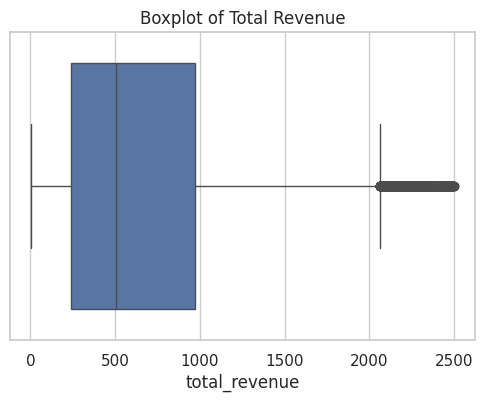

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['total_revenue'])
plt.title("Boxplot of Total Revenue")
plt.show()

In [17]:
Q1 = df['total_revenue'].quantile(0.25)
Q3 = df['total_revenue'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['total_revenue'] < lower) | (df['total_revenue'] > upper)]


In [18]:
df_no_outliers = df[(df['total_revenue'] >= lower) & (df['total_revenue'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (50000, 13)
After removing outliers:  (49248, 13)


In [19]:
lower_cap = df['total_revenue'].quantile(0.05)
upper_cap = df['total_revenue'].quantile(0.95)

df_capped = df.copy()
df_capped['total_revenue'] = df_capped['total_revenue'].clip(lower_cap, upper_cap)

In [20]:
df[['total_revenue', 'quantity_sold']].head()

,total_revenue,quantity_sold
0,463.52,4
1,1210.40,5
2,793.28,2
3,1264.64,4
4,806.72,4


In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['total_revenue', 'quantity_sold']].copy()

df_scaled[['total_revenue', 'quantity_sold']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,total_revenue,quantity_sold
0,0.184188,0.75
1,0.483454,1.00
2,0.316319,0.25
3,0.505187,0.75
4,0.321704,0.75


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['total_revenue', 'quantity_sold']].copy()

df_standardized[['total_revenue', 'quantity_sold']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,total_revenue,quantity_sold
0,-0.368310,0.706945
1,1.051024,1.413465
2,0.258350,-0.706097
3,1.154099,0.706945
4,0.283891,0.706945


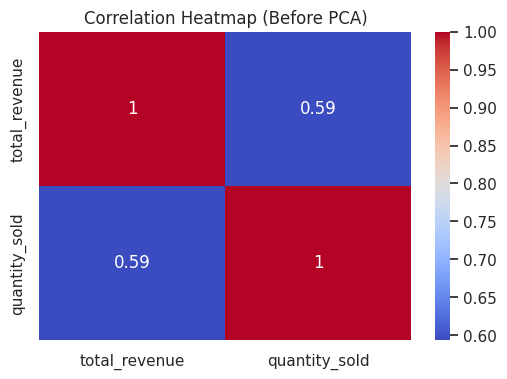

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['total_revenue','quantity_sold']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [24]:
from sklearn.decomposition import PCA

X = df_standardized[['total_revenue', 'quantity_sold']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.79720208 0.20279792]


In [25]:
# plt.figure(figsize=(6,4))
# plt.scatter(df_standardized['total_revenue'], df_standardized['quantity_sold'])
# plt.xlabel("Total Revenue (Standardized)")
# plt.ylabel("Quantity Sold (Standardized)")
# plt.title("Scatter Plot: Total Revenue vs Quantity Sold")
# plt.show()

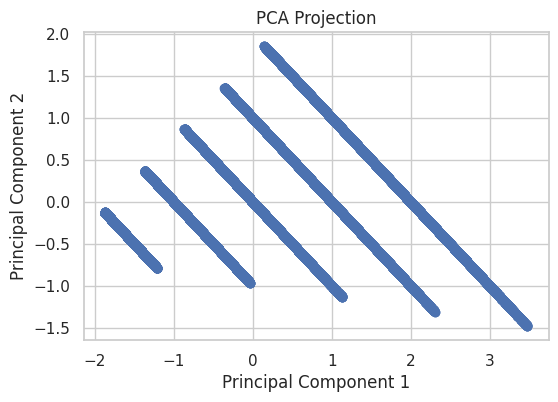

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()